In [20]:
#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.process_time_ns()
print('---------------------------------------')
print(time.strftime("PLSmethods.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import tqdm
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from scipy.ndimage import median_filter
from pybaselines import Baseline
from sklearn.metrics import root_mean_squared_error
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from functions_pixe import *
from polygauss import *
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.process_time_ns()
elapsed_setup = (end_setup - start_setup)/1e6

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.4f} ms)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
PLSmethods.ipynb started: Fri, 12 Jun 2026 11:42:18
INFO: SETUP COMPLETE (0.0000 ms)
---------------------------------------


In [3]:
def rmse(data:list, fit:list, length:int):
    '''
    Root-Mean-Square-Error
    '''
    data = np.array(data)
    fit = np.array(fit)
    return root_mean_squared_error(data, fit)

def rmse_gcv(data:list, fit:list, length:int):
    '''
    Root-Mean-Square-Error gap-cross-validation
    compare: Eilers_2003
    '''

In [4]:
def both_chi_squared(bin_data:list, fit_data:list, params:list):
    bin_data = np.array(bin_data)
    fit_data = np.array(fit_data)
    dof = len(bin_data) - len(params)
    var = np.sqrt(np.var(bin_data))
    return sum(((fit_data-bin_data)/ var)**2), sum(((fit_data-bin_data)/ var)**2) / dof

def goodness_of_fit(bin_data:list, fit_data:list):
    bin_data = np.array(bin_data)
    fit_data = np.array(fit_data)
    
    rss = sum((bin_data - fit_data)**2)
    tss = sum((bin_data - np.average(bin_data))**2)
    return 1 - rss/tss

In [5]:
def arpls_baseline(bin_data:list, bins:list, lam:int = 1e2):
    bsl_fitter = Baseline(x_data=bins)
    
    baseline, params = bsl_fitter.arpls(bin_data, lam=lam, max_iter=2000)
    subtracted = bin_data - baseline
    return baseline, subtracted

def aspls_baseline(bin_data:list, bins:list, lam:int = 1e2):
    bsl_fitter = Baseline(x_data=bins)
    
    baseline, params = bsl_fitter.aspls(bin_data, lam=lam, max_iter=200)
    subtracted = bin_data - baseline
    return baseline, subtracted

### Signal-to-Noise Ratio $SNR$

The Power-value of a signal (or the noise) is the mean of the signal (noise) squared so $P = N^{-1}\cdot\sum_{i=0}^{N} y_{i}^2$.

The $SNR$ is now just $SNR_{dB} = 10\log_{10}(\dfrac{P_{Signal}}{P_{Noise}})$.

Reversing this calculation gives the possibility to set a specific $SNR$ through: $P_{Noise} = \sqrt{\dfrac{P_{Signal}}{10^{(SNR_{dB}/10)}}}$.

In [6]:
def toy_model(N:int, snr:int, baseline_type:str, plot_flag:bool, D:int=0):
    rng = np.random.default_rng()
    
    x = np.linspace(0,8191,8192)
    # GAUSS
    heights = rng.integers(low=100, high=5e4, size=N)
    widths = rng.integers(low=10, high=100, size=N)
    centers = rng.integers(low=100, high=8100, size=N)
    # print(heights, widths, centers)
    gauss_info = []
    for i in range(0,N):
        gauss_info.append(heights[i])
        gauss_info.append(centers[i])
        gauss_info.append(widths[i])
        
    peak_data = multi_gauss(gauss_info, x)
    P_signal = np.mean(peak_data**2)
    
    # BASELINE
    if (baseline_type == 'sine'):
        if (N > 5):
            sine_amp = rng.uniform(low=10000, high=2000*N)
        else:
            sine_amp = rng.uniform(low=10000, high=10000 + 2000*N)
        sine_freq = rng.uniform(low=0.00025, high=0.0006)
        sine_shift = rng.uniform(low=0, high=10000)
        bsl_param = [sine_amp, sine_freq, sine_shift]
        baseline = sine_amp*np.sin(sine_freq*x + sine_shift)
    elif (baseline_type == 'lin'):
        offset = rng.uniform(low=-1000, high=10000)
        steep = rng.uniform(low=-4, high=4)
        bsl_param = [offset,steep]
        baseline = offset + x*steep
    elif (baseline_type == 'exp'):
        # a*e^{bx+c}
        exp_a = rng.uniform(low=10, high=20*N)
        exp_b = rng.uniform(low=-1e-3, high=-1e-4)
        exp_c = rng.uniform(low=4, high=8)
        bsl_param = [exp_a, exp_b, exp_c]
        baseline = exp_a*np.exp(exp_b*x + exp_c)
    elif (baseline_type == 'poly'):
        degree = D
        poly_param = rng.uniform(low=-0.2, high=0.2, size=D+1)
        poly = np.polynomial.polynomial.Polynomial(poly_param)
        baseline = poly(x/100)
        bsl_param = poly_param
    
       
    # NOISE
    P_noise = P_signal / (10**(snr/10))
    sigma_noise = np.sqrt(P_noise)
    noise = rng.normal(loc=0.0, scale=sigma_noise, size=8192)
    # print(noise)
    # print(f'SNR: {snr:.3f}')
    
    if (plot_flag == True):
        plt.figure(figsize=(20,4), dpi=250)
        plt.plot(x, peak_data, zorder=3, color='black', label='pure data')
        plt.plot(x, peak_data + noise + baseline, zorder=2, color='firebrick', label='full synthetic data')
        # plt.plot(x, peak_data + baseline + 10000)
        plt.plot(x, baseline, color='teal', zorder=1, label='pure baseline')
        plt.grid(axis='y')
        plt.legend()
        plt.show()
    
    toy_model_data = {
        "Bins": x,
        "NumberOfPeaks": N,
        "SNR": snr,
        "GaussianPeaks": gauss_info,
        "Noise": noise,
        "BaselineType": baseline_type,
        "BaselineParameter": bsl_param,
        "Baseline": baseline,
        "SyntheticData": peak_data+noise+baseline       
    }
    return toy_model_data

In [ ]:
def evaluate_baseline(toy_model_data:dict):
    
    plt.figure(figsize=(20,4), dpi=250)
    plt.grid(axis='y', which='both')
    
    lambda_range = np.linspace(4,14,2001)
    
    bins = toy_model_data['Bins']
    data = toy_model_data['SyntheticData']
    real_bsl = toy_model_data['Baseline']
    lam_min = [0,0]
    minimum = [1e5,1e5]
    res_list = [[],[]]
    for lam in tqdm.tqdm(lambda_range):
        arpls_bsl,_ = arpls_baseline(data, bins, 10**lam)
        arpls_result = rmse(real_bsl,arpls_bsl, 8192)
        res_list[0].append(arpls_result)
        if arpls_result < minimum[0]:
            minimum[0] = arpls_result
            lam_min[0] = lam
        
        aspls_bsl,_ = aspls_baseline(data, bins, 10**lam)
        aspls_result = rmse(real_bsl,aspls_bsl, 8192)
        res_list[1].append(aspls_result)
        if aspls_result < minimum[1]:
            minimum[1] = aspls_result
            lam_min[1] = lam
            
        # print(f'{lam:.4f}: {result:.4f}')
        # plt.plot(bins,arpls_bsl)
    # plt.plot(bins,real_bsl, color='black')
    # plt.plot(lambda_range,res_list[0],label='arPLS')
    # plt.plot(lambda_range,res_list[1],label='asPLS')
    # plt.legend()
    # plt.ylim(1,20000)
    # plt.yscale('log')
    print(f'arPLS: Minimum: {lam_min[0]:.2f}: {minimum[0]:.2f} / {(minimum[0]/(data.mean())):.3f}')
    print(f'asPLS: Minimum: {lam_min[1]:.2f}: {minimum[1]:.2f} / {(minimum[1]/(data.mean())):.3f}')
    
    
    # as_min,_ = aspls_baseline(data, bins, 10**lam_min[1])
    # ar_min,_ = arpls_baseline(data, bins, 10**lam_min[0])
    
    # plt.figure(figsize=(20,4), dpi=250)
    # plt.grid(axis='y', which='both')
    # plt.plot(bins, real_bsl, label='real Baseline')
    # plt.plot(bins, as_min, label='asPLS Baseline')
    # plt.plot(bins, ar_min, label='arPLS Baseline')
    # plt.legend()
    return {
        "arpls_lambda": lam_min[0],
        "arpls_rmse": minimum[0],
        "aspls_lambda": lam_min[1],
        "aspls_rmse": minimum[1]}   
    

In [8]:
def load_data(filename:str):
    data = read_json_formatted_file(filename)
    
    bin_data = np.array(data['RawData'][:-1])
    bins = np.arange(0,len(bin_data),1)
    bin_data_zerofixed = np.where(bin_data == 0, 1, bin_data)
    data_err = np.sqrt(bin_data_zerofixed)
    
    meas_name = filename.split('//')[3].split('.')[0]
    meas_folder = filename.split('//')[2]

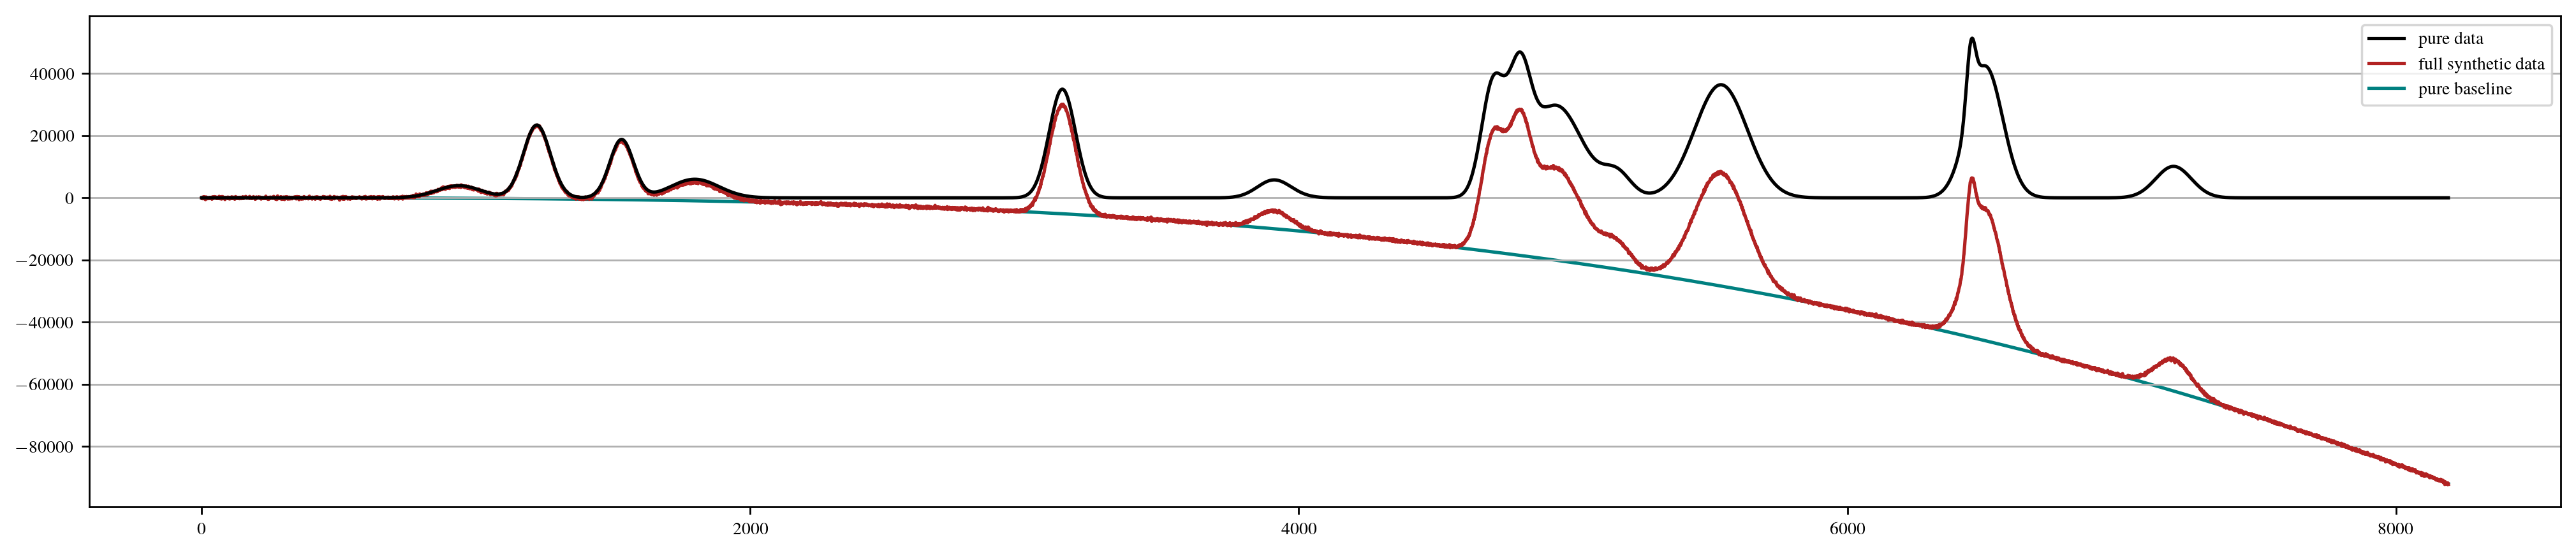

{'Bins': array([0.000e+00, 1.000e+00, 2.000e+00, ..., 8.189e+03, 8.190e+03,
       8.191e+03], shape=(8192,)), 'NumberOfPeaks': 15, 'SNR': 35, 'GaussianPeaks': [np.int64(23431), np.int64(1222), np.int64(49), np.int64(10129), np.int64(7189), np.int64(65), np.int64(5984), np.int64(1798), np.int64(88), np.int64(389), np.int64(3977), np.int64(61), np.int64(7583), np.int64(5159), np.int64(52), np.int64(19934), np.int64(6450), np.int64(16), np.int64(18754), np.int64(1531), np.int64(43), np.int64(35898), np.int64(4709), np.int64(43), np.int64(34980), np.int64(3138), np.int64(48), np.int64(29708), np.int64(4937), np.int64(97), np.int64(3906), np.int64(938), np.int64(81), np.int64(5567), np.int64(3908), np.int64(60), np.int64(42424), np.int64(6502), np.int64(64), np.int64(36417), np.int64(5539), np.int64(96), np.int64(32199), np.int64(4805), np.int64(39)], 'Noise': array([ -60.22556211,   -1.83839282,  -72.23938272, ..., -140.19351926,
        150.67443556, -224.64014305], shape=(8192,)), 'Base

100%|██████████| 2001/2001 [01:01<00:00, 32.50it/s]


arPLS: Minimum: 9.42: 87.31 / -0.005
asPLS: Minimum: 11.32: 72.79 / -0.004


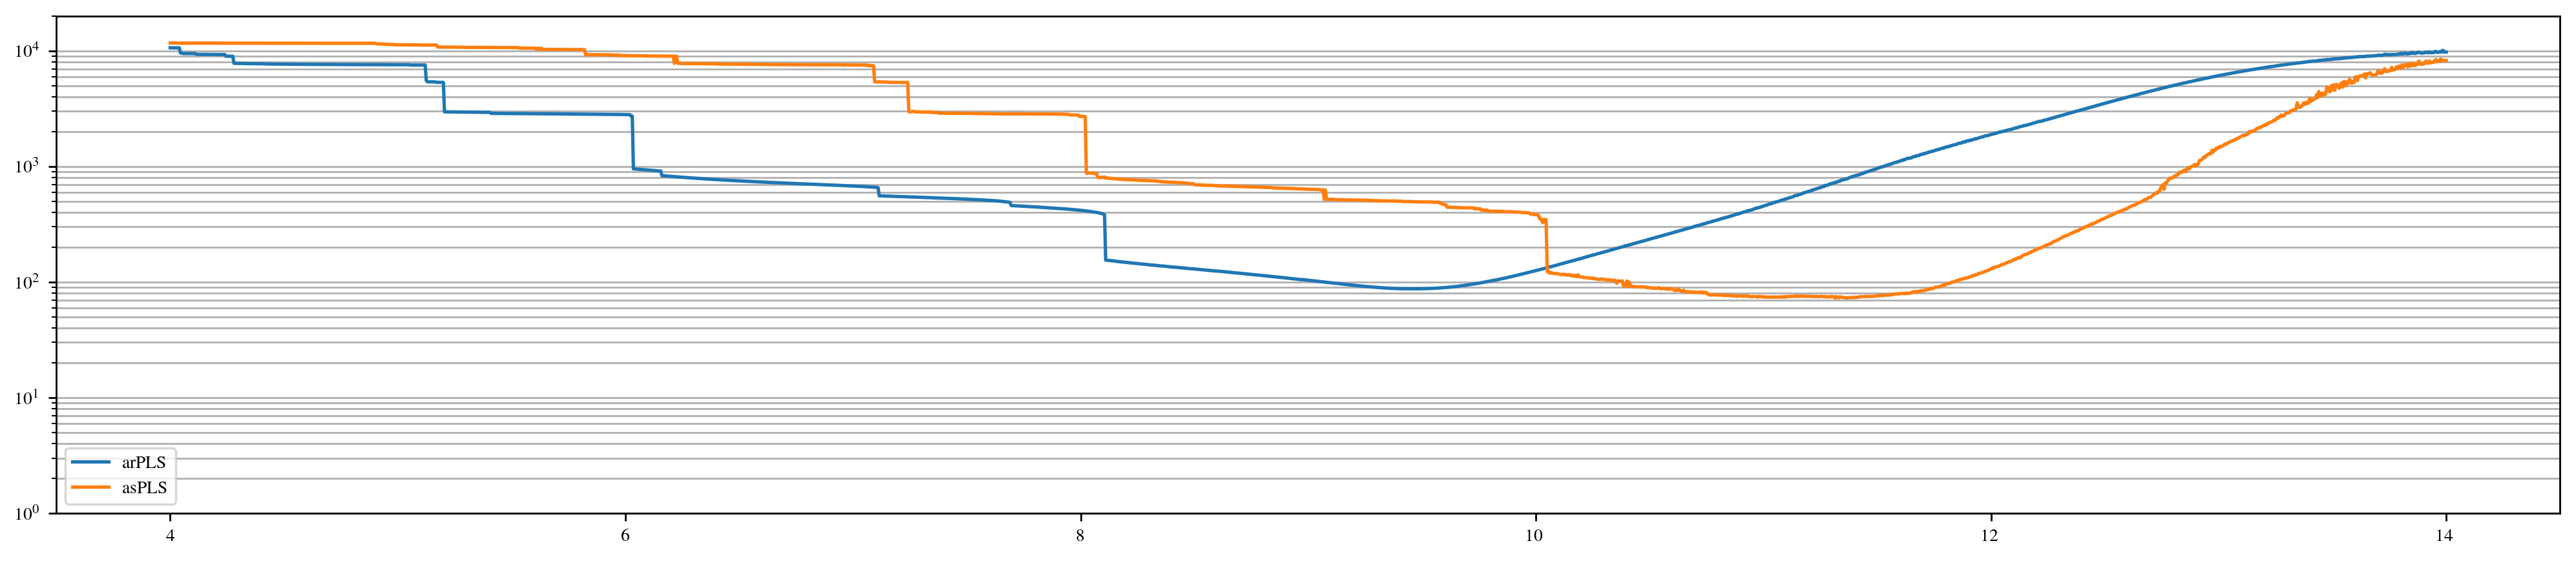

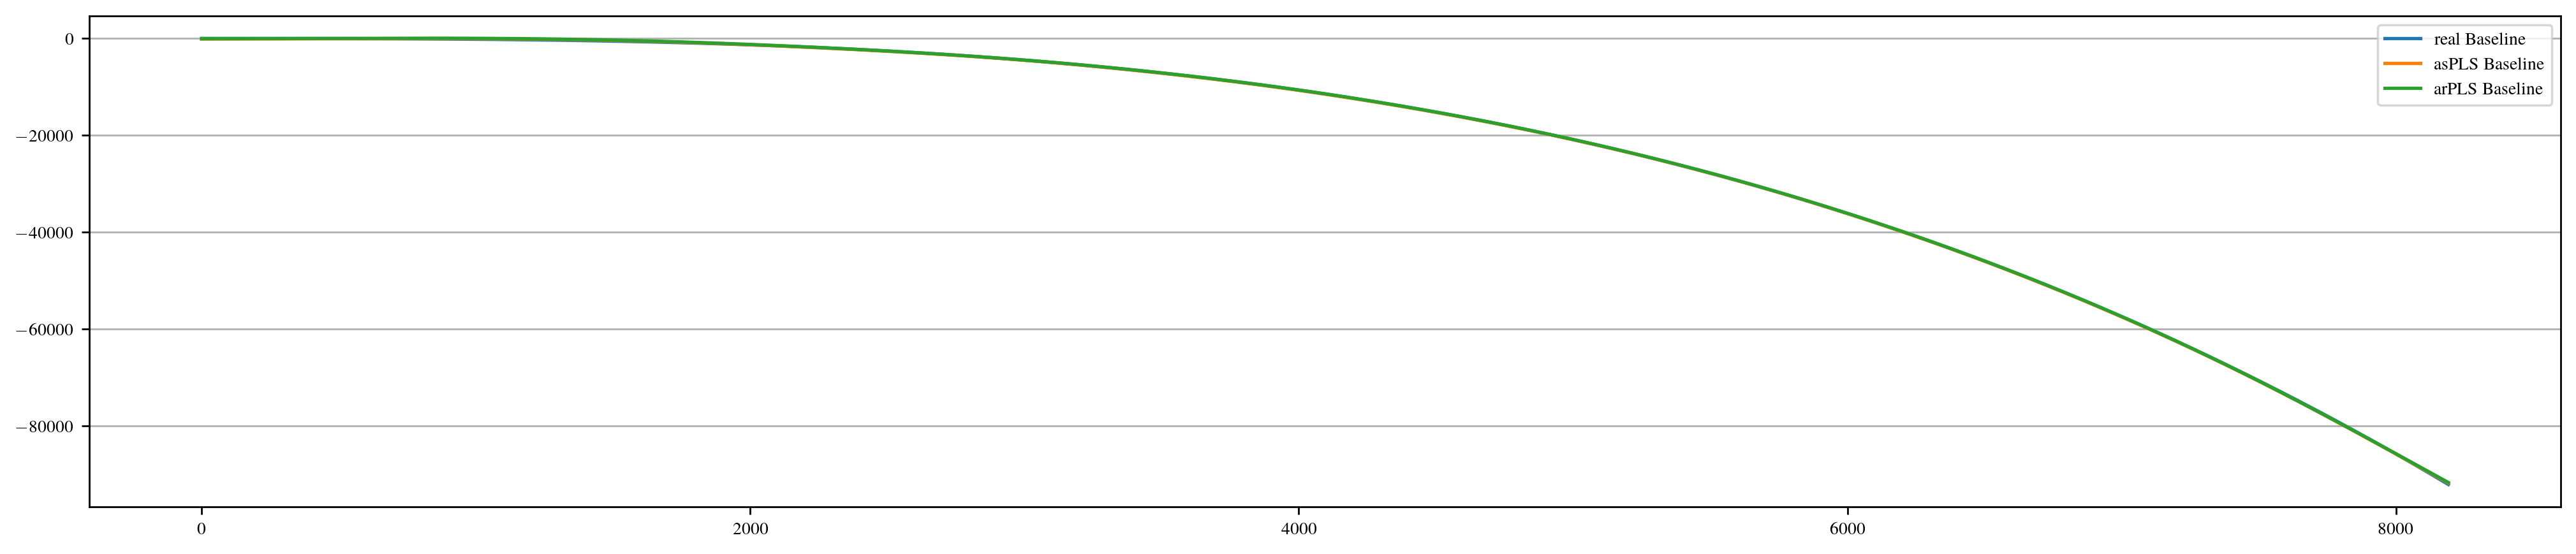

In [9]:
tmd = toy_model(N=15, snr=35, baseline_type='poly', plot_flag=True, D=3)

print(tmd)

evaluate_baseline(tmd)

# tmd = toy_model(N=40, snr=30, baseline_type='lin', plot_flag=True)

# print(tmd)

# tmd = toy_model(N=40, snr=30, baseline_type='sine', plot_flag=True)

# print(tmd)

To estimate the run time to produce a certain model, 9 sets of 1000 synthetic spectra each were produced. Each spectrum had an $SNR = 30$. The number of peaks were varied $N = 8, 40, 100$. For each set of 3x1000 spectra one baseline type was chosen (exponential, sinusoidal, linear). They were run back to back:

Spectra per second (Laptop)

$N = 8$: exp: 185.08 | sine: 180.69 | lin: 159.26 

$N = 40$: exp: 40.44 | sine: 40.33 | lin: 40.58

$N = 100$: exp: 16.55 | sine: 16.49 | lin: 15.89

In [10]:
for t in tqdm.tqdm(range(1000)):
    toy_model(N=40, snr=30, baseline_type='exp', plot_flag=False)
for t in tqdm.tqdm(range(1000)):
    toy_model(N=100, snr=30, baseline_type='exp', plot_flag=False)
for t in tqdm.tqdm(range(1000)):
    toy_model(N=8, snr=30, baseline_type='exp', plot_flag=False)

100%|██████████| 1000/1000 [00:00<00:00, 1398.36it/s]


In [11]:
for t in tqdm.tqdm(range(1000)):
    toy_model(N=40, snr=30, baseline_type='sine', plot_flag=False)
for t in tqdm.tqdm(range(1000)):
    toy_model(N=100, snr=30, baseline_type='sine', plot_flag=False)
for t in tqdm.tqdm(range(1000)):
    toy_model(N=8, snr=30, baseline_type='sine', plot_flag=False)

100%|██████████| 1000/1000 [00:00<00:00, 1414.64it/s]


In [12]:
for t in tqdm.tqdm(range(1000)):
    toy_model(N=40, snr=30, baseline_type='lin', plot_flag=False)
for t in tqdm.tqdm(range(1000)):
    toy_model(N=100, snr=30, baseline_type='lin', plot_flag=False)
for t in tqdm.tqdm(range(1000)):
    toy_model(N=8, snr=30, baseline_type='lin', plot_flag=False)

100%|██████████| 1000/1000 [00:00<00:00, 1428.66it/s]


In [13]:
for t in tqdm.tqdm(range(1000)):
    toy_model(N=40, snr=30, baseline_type='poly', plot_flag=False, D=3)
for t in tqdm.tqdm(range(1000)):
    toy_model(N=100, snr=30, baseline_type='poly', plot_flag=False, D=3)
for t in tqdm.tqdm(range(1000)):
    toy_model(N=8, snr=30, baseline_type='poly', plot_flag=False, D=3)

100%|██████████| 1000/1000 [00:00<00:00, 1408.84it/s]


In [14]:
for t in tqdm.tqdm(range(1000)):
    toy_model(N=40, snr=30, baseline_type='poly', plot_flag=False, D=3)
for t in tqdm.tqdm(range(1000)):
    toy_model(N=40, snr=30, baseline_type='poly', plot_flag=False, D=6)
for t in tqdm.tqdm(range(1000)):
    toy_model(N=40, snr=30, baseline_type='poly', plot_flag=False, D=9)

100%|██████████| 1000/1000 [00:02<00:00, 338.68it/s]


In [15]:
def single_experiment(args):
    N, snr, baseline_type, D = args
    
    model = toy_model(N=N, snr=snr, baseline_type=baseline_type, plot_flag=False, D=D)
    
    result = evaluate_baseline(model)
    
    return result

In [24]:
jobs = [[8,30,'sine',0] for _ in range(100)]
results = []
with ProcessPoolExecutor(max_workers=10) as executor:
    futures = [executor.submit(single_experiment, job) for job in jobs]

    for future in tqdm.tqdm(as_completed(futures), total=len(futures)):
        results.append(future.result())
    
print(f'Completed {len(results)} experiments!')

  0%|          | 0/100 [00:00<?, ?it/s]


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.